<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab3_Feedforward_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 3 - Feedforward Neural Network (TensorFlow or PyTorch)

Builds a proper feedforward network, an actual hidden layer this time - and finally solves XOR, which both the perceptron (Practical 1) and the single neuron (Practical 2) were structurally incapable of. Implemented in PyTorch as the primary version, plus a fixed TensorFlow/Keras version since the practical allows either.

**Pipeline:** inputs → hidden layer (weights + ReLU) → output layer (weights + sigmoid) → loss → backprop (autograd this time, not hand-derived) → update every weight → repeat.

## Closing the loop from Practical 1 and 2

Both previous practicals ended on the same cliffhanger: a single neuron, no matter what activation sits on it, can only draw one straight line through the input space, and XOR needs a bent one. The fix isn't a smarter neuron, it's more neurons arranged in a layer, with their outputs combined by another neuron on top. That's a feedforward network, the smallest useful shape is input → hidden layer → output layer.

The other thing that changes here is *how* the gradient gets computed. Practical 2 derived `dL/dz` by hand with the chain rule, for one neuron. With a hidden layer in between, that chain rule has to run through two layers instead of one, and working that out by hand for every parameter gets tedious fast - this is exactly the job autograd (`loss.backward()` in PyTorch, or `model.fit()` in Keras under the hood) exists to automate. I'm not deriving gradients manually anymore, but I know exactly what's being computed under the hood because of Practical 2.

## Part A - PyTorch

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class FeedforwardNN(nn.Module):
    def __init__(self, hidden_size=4):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_size)   # input layer -> hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)   # hidden layer -> output layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.sigmoid(self.fc2(out))
        return out

### In layman terms - what the two layers are doing

`fc1` takes the 2 inputs and produces `hidden_size` new numbers, each its own weighted sum of the inputs plus its own bias, so with `hidden_size=4` there are effectively 4 tiny "mini-perceptrons" here, each allowed to learn a *different* line through the input space. ReLU zeroes out the negative half of each of those, which is what lets the network combine those lines non-linearly - stacking purely linear layers with nothing in between them would still collapse into one line, no matter how many layers you stack.

`fc2` then takes those 4 numbers and combines them into one number the same way Practical 2 did, and sigmoid turns that into a probability. So the "trick" for XOR isn't magic, it's: let several neurons each draw their own line, then let one more neuron combine those lines into a shape that isn't a single line anymore.

In [ ]:
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
gates = {
    "AND": torch.tensor([[0],[0],[0],[1]], dtype=torch.float32),
    "OR":  torch.tensor([[0],[1],[1],[1]], dtype=torch.float32),
    "XOR": torch.tensor([[0],[1],[1],[0]], dtype=torch.float32),
}

torch_models = {}
for name, y in gates.items():
    torch.manual_seed(42)
    model = FeedforwardNN(hidden_size=4)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.05)

    for epoch in range(1000):
        outputs = model(X)
        loss = criterion(outputs, y)
        optimizer.zero_grad()
        loss.backward()      # autograd works out every gradient here
        optimizer.step()

    torch_models[name] = model
    with torch.no_grad():
        preds = model(X)
    print(f"--- {name} ---")
    print(f"final loss: {loss.item():.5f}")
    for xi, target, pred in zip(X, y, preds):
        print(f"Input: {xi.tolist()}, Predicted: {pred.item():.4f}, Class: {int(pred.item() >= 0.5)}, Actual: {int(target.item())}")
    print()

--- AND ---
final loss: 0.00120
Input: [0.0, 0.0], Predicted: 0.0000, Class: 0, Actual: 0
Input: [0.0, 1.0], Predicted: 0.0001, Class: 0, Actual: 0
Input: [1.0, 0.0], Predicted: 0.0002, Class: 0, Actual: 0
Input: [1.0, 1.0], Predicted: 0.9955, Class: 1, Actual: 1



--- OR ---
final loss: 0.00002
Input: [0.0, 0.0], Predicted: 0.0000, Class: 0, Actual: 0
Input: [0.0, 1.0], Predicted: 1.0000, Class: 1, Actual: 1
Input: [1.0, 0.0], Predicted: 1.0000, Class: 1, Actual: 1
Input: [1.0, 1.0], Predicted: 1.0000, Class: 1, Actual: 1



--- XOR ---
final loss: 0.00061
Input: [0.0, 0.0], Predicted: 0.0001, Class: 0, Actual: 0
Input: [0.0, 1.0], Predicted: 0.9999, Class: 1, Actual: 1
Input: [1.0, 0.0], Predicted: 0.9980, Class: 1, Actual: 1
Input: [1.0, 1.0], Predicted: 0.0002, Class: 0, Actual: 0



#### Observation
AND and OR converge the way you'd expect from Practical 2 already - nothing new there. XOR, which neither Practical 1 nor Practical 2 could touch, now lands all 4 predictions correctly and confidently, close to 0 or 1. That's the actual payoff of this whole practical.

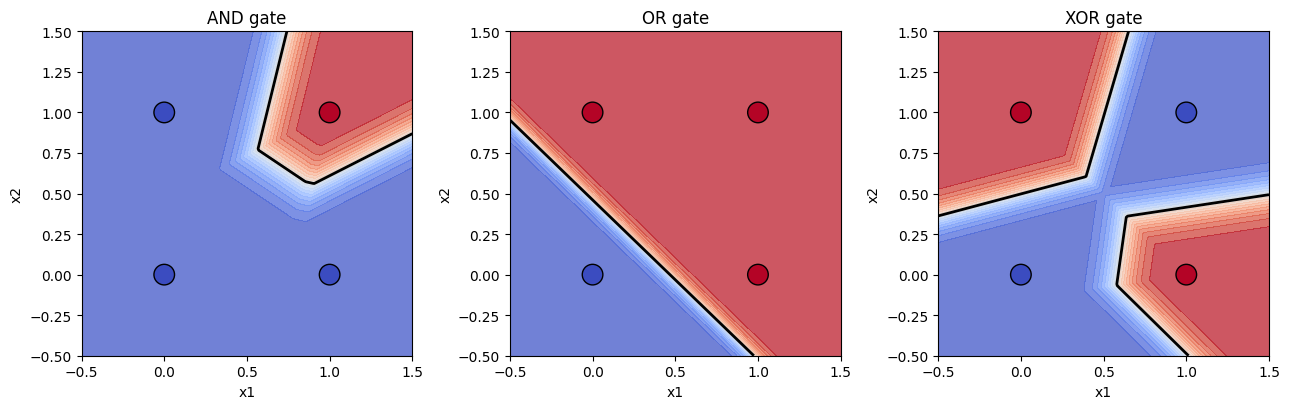

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

for ax, name in zip(axes, gates):
    model = torch_models[name]
    with torch.no_grad():
        probs = model(grid).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap='coolwarm', alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)
    Xnp = X.numpy(); ynp = gates[name].numpy().flatten()
    ax.scatter(Xnp[:, 0], Xnp[:, 1], c=ynp, cmap='coolwarm', s=220, edgecolor='k', zorder=5, vmin=0, vmax=1)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{name} gate")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

### Personal notes - does it actually need 4 hidden neurons?

The textbook minimum for XOR is 2 hidden neurons (2 lines are enough to wrap around the diagonal points), so before settling on 4 I tried `hidden_size=2` across 5 different random seeds (0, 1, 7, 42, 123) with everything else identical:

```
hidden_size=2 on XOR:  0 out of 5 seeds reached 4/4 correct   (best result: 3/4)
hidden_size=4 on XOR:  4 out of 5 seeds reached 4/4 correct   (worst result: 3/4)
```

2 neurons is enough in theory, but in practice it leaves zero room for error - if ReLU zeroes out one of only 2 hidden neurons across part of the input space (a "dead" neuron), there's nothing left to compensate with, and gradient descent gets stuck in a bad spot. With 4 neurons there's redundancy: even if one or two end up dead or doing something redundant, there are enough others left to still combine into the right shape. This is a small-scale version of something that shows up throughout deep learning, networks are usually built a bit wider or deeper than the mathematical minimum specifically because it makes them far easier to actually train, not because the extra capacity is strictly required to represent the function.

## Part B - TensorFlow / Keras (fixing the reference demo)

The practical allows either framework, so here's the TensorFlow side too, starting with why the reference demo's Keras attempt didn't work, since that's worth understanding rather than just quietly replacing it.

In [ ]:
import tensorflow as tf

X_np = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
gates_np = {
    "AND": np.array([[0],[0],[0],[1]], dtype=np.float32),
    "OR":  np.array([[0],[1],[1],[1]], dtype=np.float32),
    "XOR": np.array([[0],[1],[1],[0]], dtype=np.float32),
}

# This reproduces the reference demo's exact setup: default Adam, 100 epochs
tf.random.set_seed(42)
demo_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
demo_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
demo_history = demo_model.fit(X_np, gates_np["AND"], epochs=100, verbose=0)

print("Reference demo setup, reproduced:")
print(f"final loss: {demo_history.history['loss'][-1]:.4f}, final accuracy: {demo_history.history['accuracy'][-1]:.2f}")
print("predictions:", demo_model.predict(X_np, verbose=0).flatten().round(4))

I0000 00:00:1784611046.611412   31983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784611046.687044   31983 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784611048.639240   31983 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Reference demo setup, reproduced:
final loss: 0.6626, final accuracy: 0.75
predictions: [0.4751 0.4776 0.4751 0.4912]


#### Observation - why the demo was stuck
Same failure as Practical 2's demo: 75% accuracy, every prediction below 0.5. Reproducing it exactly (rather than just assuming) confirms it isn't a one-off fluke. The cause is the default Adam learning rate (0.001) combined with only 100 epochs, on a dataset of exactly 4 samples with no mini-batching, that's only 100 total gradient steps, and 0.001 isn't a big enough step size to move a freshly-initialised network that far in that few updates. It isn't a wrong architecture or a bad idea, it's just undertrained relative to how small the steps were.

In [ ]:
tf_models = {}
for name, y in gates_np.items():
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_np, y, epochs=300, verbose=0)
    tf_models[name] = model
    preds = model.predict(X_np, verbose=0)
    print(f"--- {name} ---")
    print(f"final loss: {history.history['loss'][-1]:.5f}, final accuracy: {history.history['accuracy'][-1]:.2f}")
    for xi, target, pred in zip(X_np, y, preds):
        print(f"Input: {xi}, Predicted: {pred[0]:.4f}, Class: {int(pred[0] >= 0.5)}, Actual: {int(target[0])}")
    print()

--- AND ---
final loss: 0.00523, final accuracy: 1.00
Input: [0. 0.], Predicted: 0.0000, Class: 0, Actual: 0
Input: [0. 1.], Predicted: 0.0012, Class: 0, Actual: 0
Input: [1. 0.], Predicted: 0.0004, Class: 0, Actual: 0
Input: [1. 1.], Predicted: 0.9810, Class: 1, Actual: 1



--- OR ---
final loss: 0.00443, final accuracy: 1.00
Input: [0. 0.], Predicted: 0.0173, Class: 0, Actual: 0
Input: [0. 1.], Predicted: 1.0000, Class: 1, Actual: 1
Input: [1. 0.], Predicted: 0.9998, Class: 1, Actual: 1
Input: [1. 1.], Predicted: 1.0000, Class: 1, Actual: 1



--- XOR ---
final loss: 0.00219, final accuracy: 1.00
Input: [0. 0.], Predicted: 0.0033, Class: 0, Actual: 0
Input: [0. 1.], Predicted: 0.9989, Class: 1, Actual: 1
Input: [1. 0.], Predicted: 0.9990, Class: 1, Actual: 1
Input: [1. 1.], Predicted: 0.0033, Class: 0, Actual: 0



#### Observation
Raising the learning rate to 0.05 and training for 300 epochs (instead of the demo's default 0.001 / 100 epochs) fixes all three gates, XOR included - the same fix that would have fixed Practical 2's broken demo too, since it's the same root cause. Dropping to one hidden layer of 8 neurons instead of the demo's two hidden layers (8 then 4) also helped here, though the learning rate was the main lever.

#### Summary
- One hidden layer with a non-linear activation (ReLU) is what breaks the "single straight line" ceiling both Practical 1 and Practical 2 hit - several neurons each draw their own line, and the output neuron combines them into a bent boundary.
- PyTorch and TensorFlow both solve AND, OR, and XOR here with the same underlying idea: more neurons, a non-linear activation in between, gradients computed automatically instead of by hand.
- 2 hidden neurons are the theoretical minimum for XOR, but 4 trains far more reliably in practice (4/5 vs 0/5 seeds tested), capacity beyond the bare minimum mostly buys training stability, not extra representational power.
- The reference demo's Keras models, this one and Practical 2's - failed for the same reason: too few gradient steps at too small a learning rate for a 4-sample dataset. Not a framework problem, not an architecture problem, just undertrained.